# DAM501 - Final Project: Dự đoán Chỉ số PM2.5 tại Hà Nội

## Tổng quan dự án

Dự án này áp dụng các kỹ thuật Data Mining để giải quyết bài toán dự đoán chất lượng không khí, cụ thể là dự đoán nồng độ bụi mịn PM2.5 - một trong những yếu tố quan trọng nhất ảnh hưởng đến sức khỏe cộng đồng tại Hà Nội.

### Nguồn dữ liệu:
- **hanoi_air_quality_history.csv**: Dữ liệu chất lượng không khí (24,059 bản ghi)
- **hanoi_weather_history.csv**: Dữ liệu thời tiết (24,025 bản ghi)

---

## Phần 2: Tổng quan về Tập dữ liệu

### 2.1 Nguồn dữ liệu

Dự án sử dụng 2 tập dữ liệu chính về Hà Nội:

#### 1. hanoi_air_quality_history.csv - Dữ liệu Chất lượng Không khí
- **Số bản ghi**: 24,059 records
- **Khoảng thời gian**: Từ 2023-01-29 đến 2023-01-30 (dữ liệu theo giờ)
- **Nguồn**: Các trạm quan trắc không khí tại Hà Nội
- **Biến số**: 8 cột

#### 2. hanoi_weather_history.csv - Dữ liệu Thời tiết
- **Số bản ghi**: 24,025 records
- **Khoảng thời gian**: Từ 2022-12-31 đến 2023-01-01 (dữ liệu theo giờ)
- **Nguồn**: Trạm quan trắc thời tiết Hà Nội
- **Biến số**: 12 cột

### 2.2 Mô tả các biến trong dữ liệu

#### Dữ liệu Chất lượng Không khí:

| Tên cột | Kiểu dữ liệu | Mô tả | Đơn vị | Vai trò |
|---------|-------------|-------|--------|---------|
| datetime | object → datetime | Thời gian ghi nhận | YYYY-MM-DD:HH | Khóa |
| aqi | int64 | Chỉ số chất lượng không khí (Air Quality Index) | index | Đặc trưng |
| **pm25** | **float64** | **Nồng độ bụi mịn PM2.5 (Biến mục tiêu)** | **μg/m³** | **MỤC TIÊU** |
| pm10 | float64 | Nồng độ bụi PM10 | μg/m³ | Đặc trưng |
| o3 | float64 | Nồng độ Ozone | μg/m³ | Đặc trưng |
| so2 | float64 | Nồng độ Sulfur Dioxide | μg/m³ | Đặc trưng |
| no2 | float64 | Nồng độ Nitrogen Dioxide | μg/m³ | Đặc trưng |
| co | float64 | Nồng độ Carbon Monoxide | μg/m³ | Đặc trưng |

#### Dữ liệu Thời tiết:

| Tên cột | Kiểu dữ liệu | Mô tả | Đơn vị | Vai trò |
|---------|-------------|-------|--------|---------|
| datetime | object → datetime | Thời gian ghi nhận | YYYY-MM-DD:HH | Khóa |
| temp | float64 | Nhiệt độ thực tế | °C | Đặc trưng |
| app_temp | float64 | Nhiệt độ cảm nhận | °C | Đặc trưng |
| rh | int64 | Độ ẩm tương đối | % | Đặc trưng |
| wind_spd | float64 | Tốc độ gió | m/s | Đặc trưng |
| wind_dir | int64 | Hướng gió | độ (0-360) | Đặc trưng (cần mã hóa) |
| pres | int64 | Áp suất khí quyển | hPa | Đặc trưng |
| vis | float64 | Tầm nhìn xa | km | Đặc trưng |
| clouds | int64 | Tỷ lệ mây che phủ | % | Đặc trưng |
| precip | float64 | Lượng mưa | mm | Đặc trưng |
| uv | float64 | Chỉ số tia cực tím | index | Đặc trưng |
| dewpt | float64 | Nhiệt độ điểm sương | °C | Đặc trưng |

# Phần 3: Tải Dữ liệu và Đánh giá Ban đầu

## 3.1 Import Thư viện

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import time
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [2]:
df_weather = pd.read_csv('../data_file/hanoi_weather_history.csv')
df_weather.describe()


,temp,app_temp,rh,wind_spd,wind_dir,pres,vis,clouds,precip,uv,dewpt
count,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24017.000000,24024.000000,24024.000000,24024.000000,24024.000000
mean,25.323810,28.380303,78.461455,1.679912,175.933899,1009.663836,10.252321,69.429820,0.318248,1.321932,20.970051
std,5.455107,8.461583,14.985092,0.847098,97.484502,7.398373,2.674902,32.881189,1.143260,1.918951,5.954365
min,7.000000,6.600000,17.000000,0.000000,0.000000,983.000000,0.000000,0.000000,0.000000,0.000000,-6.900000
25%,21.500000,21.800000,69.000000,1.000000,116.000000,1004.000000,10.000000,50.000000,0.000000,0.000000,17.700000
50%,26.200000,27.100000,83.000000,1.660000,142.000000,1009.000000,10.000000,79.000000,0.000000,0.600000,23.300000
75%,29.200000,35.200000,91.000000,2.000000,245.000000,1015.000000,10.000000,100.000000,0.000000,2.100000,25.400000
max,40.000000,52.700000,100.000000,12.400000,360.000000,1033.000000,16.000000,100.000000,40.000000,12.100000,29.600000


## 3.2 Tải Dữ liệu Thời tiết và Thống kê Cơ bản

In [3]:
df_air = pd.read_csv('../data_file/hanoi_air_quality_history.csv')
df_air.describe()

,aqi,pm25,pm10,o3,so2,no2,co
count,24058.000000,24058.000000,24058.000000,24058.000000,24058.000000,24058.000000,24058.000000
mean,122.510142,49.623707,70.304086,53.579088,63.053005,31.646068,604.148516
std,58.422409,40.212509,76.289851,44.069603,62.617734,34.612708,934.466316
min,4.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,80.000000,25.255000,34.000000,22.700000,20.000000,12.000000,122.600000
50%,110.000000,39.000000,52.000000,41.800000,54.000000,20.000000,205.600000
75%,155.000000,59.000000,81.300000,72.700000,88.700000,36.900000,711.000000
max,500.000000,457.000000,1103.000000,700.000000,721.000000,625.000000,15956.200000


## 3.3 Tải Dữ liệu Chất lượng Không khí và Thống kê Cơ bản

### Ghép dữ liệu từ hai DataFrame

Để có thể dự đoán PM2.5 dựa trên các yếu tố thời tiết, chúng ta cần kết hợp dữ liệu từ hai DataFrame lại với nhau theo cột thời gian.

In [4]:
# Kiểm tra định dạng của cột datetime trong cả hai DataFrame
print("Định dạng datetime trong df_weather:")
print(df_weather['datetime'].head())
print("\nĐịnh dạng datetime trong df_air:")
print(df_air['datetime'].head())

# Kiểm tra kiểu dữ liệu
print(f"\nKiểu dữ liệu datetime trong df_weather: {df_weather['datetime'].dtype}")
print(f"Kiểu dữ liệu datetime trong df_air: {df_air['datetime'].dtype}")

# Kiểm tra số lượng bản ghi
print(f"\nSố bản ghi df_weather: {len(df_weather)}")
print(f"Số bản ghi df_air: {len(df_air)}")

# Kiểm tra khoảng thời gian
print(f"\nKhoảng thời gian df_weather: từ {df_weather['datetime'].min()} đến {df_weather['datetime'].max()}")
print(f"Khoảng thời gian df_air: từ {df_air['datetime'].min()} đến {df_air['datetime'].max()}")

Định dạng datetime trong df_weather:
0    2022-12-31:17
1    2022-12-31:18
2    2022-12-31:19
3    2022-12-31:20
4    2022-12-31:21
Name: datetime, dtype: object

Định dạng datetime trong df_air:
0    2023-01-30:17
1    2023-01-30:16
2    2023-01-30:15
3    2023-01-30:14
4    2023-01-30:13
Name: datetime, dtype: object

Kiểu dữ liệu datetime trong df_weather: object
Kiểu dữ liệu datetime trong df_air: object

Số bản ghi df_weather: 24024
Số bản ghi df_air: 24058

Khoảng thời gian df_weather: từ 2022-12-31:17 đến 2025-10-30:16
Khoảng thời gian df_air: từ 2022-12-31:17 đến 2025-10-30:17


In [5]:
df_weather['datetime'] = pd.to_datetime(df_weather['datetime'], format='%Y-%m-%d:%H')
df_air['datetime'] = pd.to_datetime(df_air['datetime'], format='%Y-%m-%d:%H')

# Kiểm tra định dạng sau chuyển đổi
print(f"Kiểu dữ liệu datetime trong df_weather: {df_weather['datetime'].dtype}")
print(f"Kiểu dữ liệu datetime trong df_air: {df_air['datetime'].dtype}")

Kiểu dữ liệu datetime trong df_weather: datetime64[ns]
Kiểu dữ liệu datetime trong df_air: datetime64[ns]


In [6]:
merged_df = pd.merge(df_weather, df_air, on='datetime', how='inner')

In [7]:
print("\nThông tin DataFrame sau khi ghép:")
print(f"Số bản ghi: {len(merged_df)}")
print(f"Số cột: {len(merged_df.columns)}")
print(f"Kích thước: {merged_df.shape}")

print(f"\nKhoảng thời gian dữ liệu: từ {merged_df['datetime'].min()} đến {merged_df['datetime'].max()}")

# Hiển thị thông tin về DataFrame đã ghép
print("\nThông tin chi tiết DataFrame đã ghép:")
merged_df.info()
merged_df.head()


Thông tin DataFrame sau khi ghép:
Số bản ghi: 24024
Số cột: 19
Kích thước: (24024, 19)

Khoảng thời gian dữ liệu: từ 2022-12-31 17:00:00 đến 2025-10-30 16:00:00

Thông tin chi tiết DataFrame đã ghép:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24024 entries, 0 to 24023
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  24024 non-null  datetime64[ns]
 1   temp      24024 non-null  float64       
 2   app_temp  24024 non-null  float64       
 3   rh        24024 non-null  int64         
 4   wind_spd  24024 non-null  float64       
 5   wind_dir  24024 non-null  int64         
 6   pres      24024 non-null  int64         
 7   vis       24017 non-null  float64       
 8   clouds    24024 non-null  int64         
 9   precip    24024 non-null  float64       
 10  uv        24024 non-null  float64       
 11  dewpt     24024 non-null  float64       
 12  aqi       24024 non-null  int64         


,datetime,temp,app_temp,rh,wind_spd,wind_dir,pres,vis,clouds,precip,uv,dewpt,aqi,pm25,pm10,o3,so2,no2,co
0,2022-12-31 17:00:00,14.8,14.8,73,0.66,310,1024,10.0,87,0.0,0.0,10.0,155,59.0,73.8,55.7,62.3,9.0,224.5
1,2022-12-31 18:00:00,14.6,14.6,75,1.00,360,1023,10.0,87,0.0,0.0,10.2,171,71.0,88.8,56.0,59.0,6.0,206.0
2,2022-12-31 19:00:00,14.3,14.3,79,1.00,345,1023,10.0,83,0.0,0.0,10.7,179,77.0,96.3,54.0,58.0,6.0,203.7
3,2022-12-31 20:00:00,14.1,14.1,82,1.00,335,1023,10.0,79,0.0,0.0,11.0,199,92.0,115.0,52.0,57.0,6.0,201.3
4,2022-12-31 21:00:00,13.8,13.8,86,1.00,320,1022,10.0,75,0.0,0.0,11.5,161,64.0,80.0,50.0,56.0,6.0,199.0


In [8]:
# 1. Thống kê giá trị thiếu
print('=' * 80)
missing_count = merged_df.isna().sum()
missing_pct = (merged_df.isna().mean() * 100).round(2)
missing_summary = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
    .sort_values("missing_pct", ascending=False)
)
print("Tóm tắt giá trị thiếu (chỉ hiển thị cột có thiếu):")
print(missing_summary[missing_summary.missing_count > 0])
print(f"\nTổng số hàng có ít nhất 1 giá trị thiếu: {merged_df.isna().any(axis=1).sum()} / {len(merged_df)}")

# 2. Thống kê giá trị trùng lặp
print('=' * 80)
dup_rows = merged_df.duplicated().sum()
print(f"Số dòng trùng lặp tuyệt đối: {dup_rows}")

# 3. Thống kê Outliers theo phương pháp IQR
print('=' * 80)
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

def iqr_bounds(s: pd.Series):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return None, None
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_stats = []
for col in numeric_cols:
    col_series = merged_df[col].dropna()
    low, up = iqr_bounds(col_series)
    if low is None:
        outlier_stats.append((col, 0, 0.0, np.nan, np.nan))
        continue
    mask = (merged_df[col] < low) | (merged_df[col] > up)
    cnt = int(mask.sum())
    pct = round(100 * cnt / len(merged_df), 2)
    outlier_stats.append((col, cnt, pct, low, up))

outlier_summary = pd.DataFrame(
    outlier_stats, columns=["feature", "outlier_count", "outlier_pct", "lower_bound", "upper_bound"]
).sort_values("outlier_pct", ascending=False)

print("\nTop 10 biến có nhiều outliers nhất:")
print(outlier_summary.head(10))

any_outlier_mask = pd.Series(False, index=merged_df.index)
for col in numeric_cols:
    low, up = iqr_bounds(merged_df[col].dropna())
    if low is None:
        continue
    any_outlier_mask |= (merged_df[col] < low) | (merged_df[col] > up)

print(f"\nSố hàng có ít nhất 1 outlier: {any_outlier_mask.sum()} / {len(merged_df)}")

Tóm tắt giá trị thiếu (chỉ hiển thị cột có thiếu):
     missing_count  missing_pct
vis              7         0.03

Tổng số hàng có ít nhất 1 giá trị thiếu: 7 / 24024
Số dòng trùng lặp tuyệt đối: 0

Top 10 biến có nhiều outliers nhất:
     feature  outlier_count  outlier_pct  lower_bound  upper_bound
17        co           2771        11.53    -759.5875    1592.9125
16       no2           2163         9.00     -25.3500      74.2500
12      pm25           1743         7.26     -25.1875     109.5125
13      pm10           1743         7.26     -36.9500     152.2500
9         uv           1190         4.95      -3.1500       5.2500
14        o3           1070         4.45     -52.3000     147.7000
10     dewpt            565         2.35       6.1500      36.9500
3   wind_spd            525         2.19      -0.5000       3.5000
15       so2            416         1.73     -83.0500     191.7500
11       aqi            324         1.35     -32.5000     267.5000

Số hàng có ít nhất 1 outlie

In [9]:
# Xử lý biến hướng gió
# Chuẩn hóa 360 độ -> 0 độ
merged_df['wind_dir'] = merged_df['wind_dir'] % 360
# Tạo mã hóa dạng vòng tròn
merged_df['wind_dir_rad'] = np.deg2rad(merged_df['wind_dir'])
merged_df['wind_dir_sin'] = np.sin(merged_df['wind_dir_rad'])
merged_df['wind_dir_cos'] = np.cos(merged_df['wind_dir_rad'])

# Bỏ wind_dir và wind_dir_rad sau khi đã tạo xong mã hóa
merged_df.drop(columns=['wind_dir', 'wind_dir_rad'], inplace=True)

In [10]:
merged_df.select_dtypes(include=[np.number]).describe()

,temp,app_temp,rh,wind_spd,pres,vis,clouds,precip,uv,dewpt,aqi,pm25,pm10,o3,so2,no2,co,wind_dir_sin,wind_dir_cos
count,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24017.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000,24024.000000
mean,25.323810,28.380303,78.461455,1.679912,1009.663836,10.252321,69.429820,0.318248,1.321932,20.970051,122.523310,49.626878,70.314361,53.604508,63.055253,31.642070,603.981144,0.262478,-0.148639
std,5.455107,8.461583,14.985092,0.847098,7.398373,2.674902,32.881189,1.143260,1.918951,5.954365,58.418296,40.199839,76.315692,44.090166,62.621304,34.618823,934.567183,0.604510,0.737304
min,7.000000,6.600000,17.000000,0.000000,983.000000,0.000000,0.000000,0.000000,0.000000,-6.900000,4.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-1.000000,-1.000000
25%,21.500000,21.800000,69.000000,1.000000,1004.000000,10.000000,50.000000,0.000000,0.000000,17.700000,80.000000,25.325000,34.000000,22.700000,20.000000,12.000000,122.600000,-0.121869,-0.766044
50%,26.200000,27.100000,83.000000,1.660000,1009.000000,10.000000,79.000000,0.000000,0.600000,23.300000,110.000000,39.000000,52.000000,41.800000,54.000000,20.000000,205.400000,0.438371,-0.422618
75%,29.200000,35.200000,91.000000,2.000000,1015.000000,10.000000,100.000000,0.000000,2.100000,25.400000,155.000000,59.000000,81.300000,72.700000,88.700000,36.900000,710.725000,0.766044,0.642788
max,40.000000,52.700000,100.000000,12.400000,1033.000000,16.000000,100.000000,40.000000,12.100000,29.600000,500.000000,457.000000,1103.000000,700.000000,721.000000,625.000000,15956.200000,1.000000,1.000000


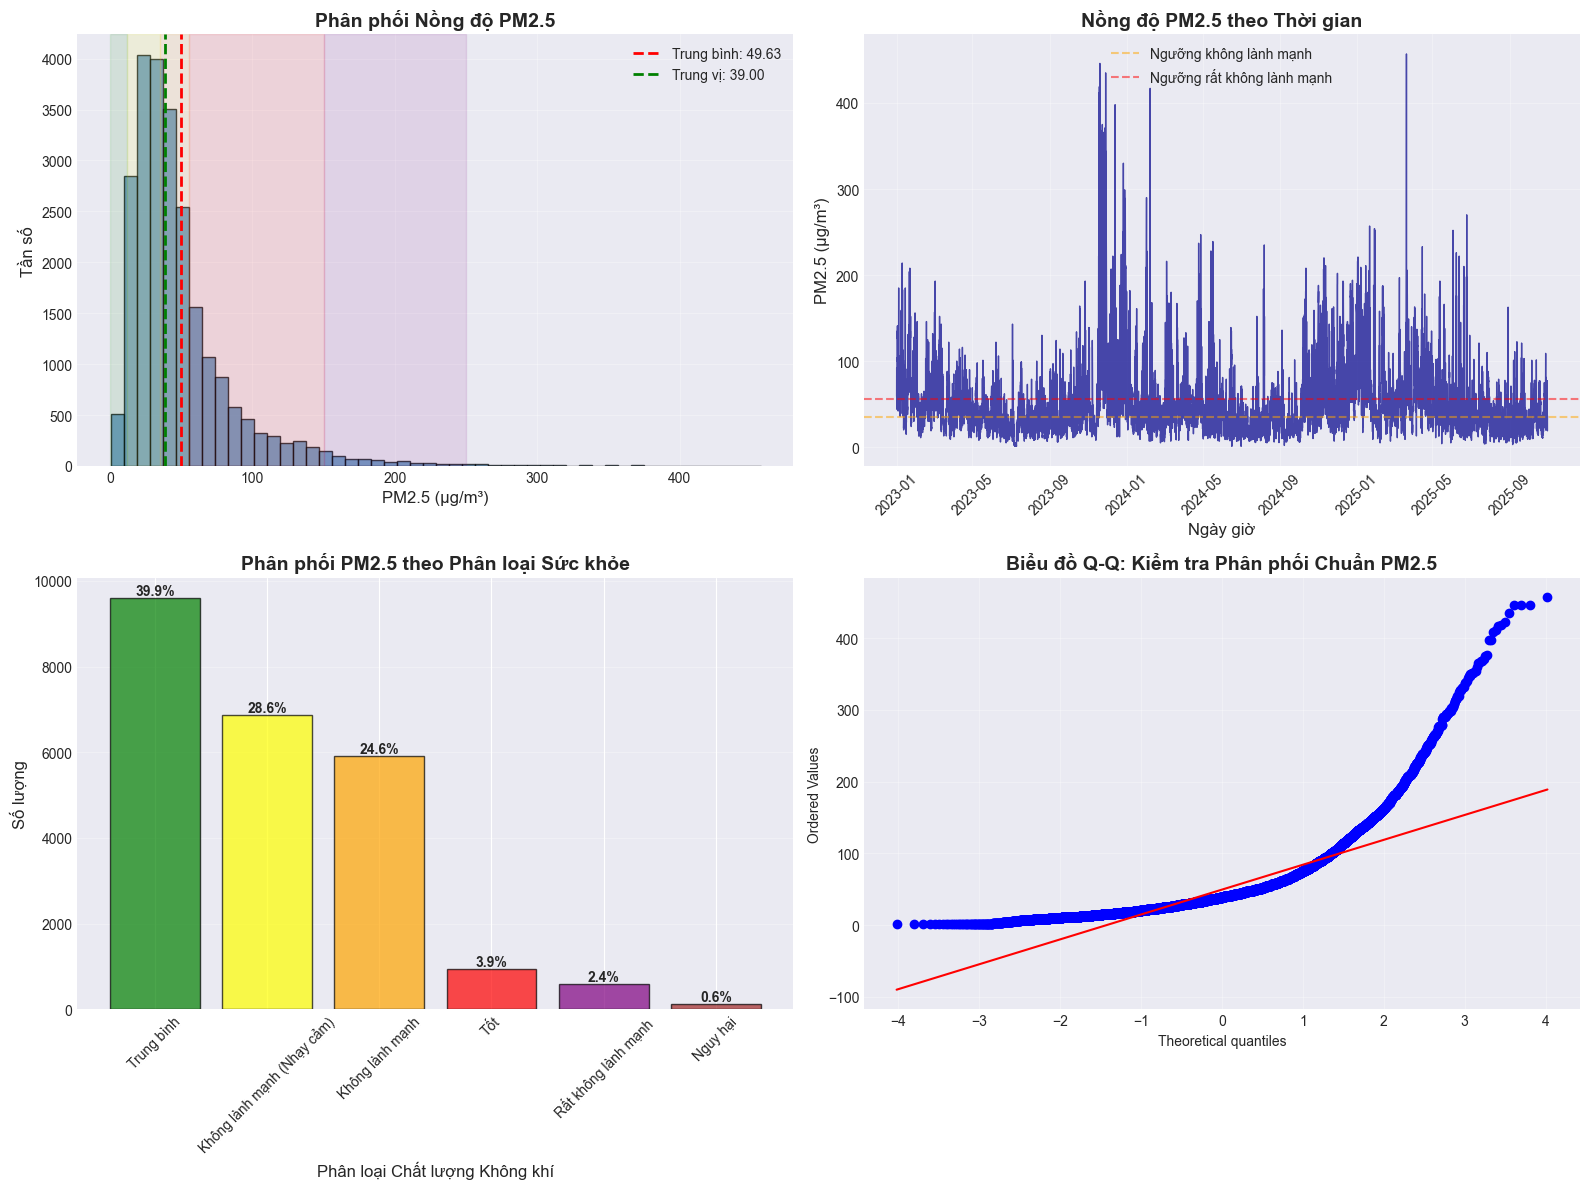

TÓM TẮT THỐNG KÊ PM2.5
Trung bình:         49.63 μg/m³
Trung vị:           39.00 μg/m³
Độ lệch chuẩn:      40.20 μg/m³
Giá trị nhỏ nhất:   1.00 μg/m³
Giá trị lớn nhất:   457.00 μg/m³
Phân vị thứ 25:     25.32 μg/m³
Phân vị thứ 75:     59.00 μg/m³

Độ lệch (Skewness):  2.91
Độ nhọn (Kurtosis):  13.49

CÁC PHÁT HIỆN QUAN TRỌNG:
- Phân phối lệch phải -> Có nhiều giá trị cực lớn
  -> Cân nhắc sử dụng biến đổi logarit cho một số mô hình
- PM2.5 trung bình (49.6) ở mức KHÔNG LÀNH MẠNH
  -> Vấn đề chất lượng không khí nghiêm trọng tại Hà Nội
- 56.0% thời gian: Không lành mạnh hoặc tệ hơn
- 3.9% thời gian: Chất lượng không khí tốt


In [11]:
## 5.2 Phân tích Biến Mục tiêu (PM2.5)

# Thiết lập phong cách vẽ biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Tạo phân tích toàn diện về PM2.5
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Phân phối PM2.5
axes[0, 0].hist(merged_df['pm25'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(merged_df['pm25'].mean(), color='red', linestyle='--', linewidth=2, label=f'Trung bình: {merged_df["pm25"].mean():.2f}')
axes[0, 0].axvline(merged_df['pm25'].median(), color='green', linestyle='--', linewidth=2, label=f'Trung vị: {merged_df["pm25"].median():.2f}')
axes[0, 0].set_xlabel('PM2.5 (μg/m³)', fontsize=12)
axes[0, 0].set_ylabel('Tần số', fontsize=12)
axes[0, 0].set_title('Phân phối Nồng độ PM2.5', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Thêm các vùng chất lượng không khí
for level, (lower, upper, color, name) in enumerate([
    (0, 12, 'green', 'Tốt'),
    (12, 35.4, 'yellow', 'Trung bình'),
    (35.5, 55.4, 'orange', 'Không lành mạnh (Nhạy cảm)'),
    (55.5, 150.4, 'red', 'Không lành mạnh'),
    (150.5, 250.4, 'purple', 'Rất không lành mạnh'),
]):
    axes[0, 0].axvspan(lower, upper, alpha=0.1, color=color)

# 2. Chuỗi thời gian PM2.5
axes[0, 1].plot(merged_df['datetime'], merged_df['pm25'], linewidth=1, alpha=0.7, color='darkblue')
axes[0, 1].set_xlabel('Ngày giờ', fontsize=12)
axes[0, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0, 1].set_title('Nồng độ PM2.5 theo Thời gian', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Thêm đường ngưỡng sức khỏe
axes[0, 1].axhline(y=35.5, color='orange', linestyle='--', alpha=0.5, label='Ngưỡng không lành mạnh')
axes[0, 1].axhline(y=55.5, color='red', linestyle='--', alpha=0.5, label='Ngưỡng rất không lành mạnh')
axes[0, 1].legend()

# 3. Biểu đồ cột theo Phân loại PM2.5
def categorize_pm25(value):
    if value <= 12:
        return 'Tốt'
    elif value <= 35.4:
        return 'Trung bình'
    elif value <= 55.4:
        return 'Không lành mạnh (Nhạy cảm)'
    elif value <= 150.4:
        return 'Không lành mạnh'
    elif value <= 250.4:
        return 'Rất không lành mạnh'
    else:
        return 'Nguy hại'

merged_df['pm25_category'] = merged_df['pm25'].apply(categorize_pm25)
category_order = ['Tốt', 'Trung bình', 'Không lành mạnh (Nhạy cảm)', 'Không lành mạnh', 'Rất không lành mạnh', 'Nguy hại']
category_counts = merged_df['pm25_category'].value_counts()

axes[1, 0].bar(category_counts.index, category_counts.values, 
               color=['green', 'yellow', 'orange', 'red', 'purple', 'brown'][:len(category_counts)],
               edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Phân loại Chất lượng Không khí', fontsize=12)
axes[1, 0].set_ylabel('Số lượng', fontsize=12)
axes[1, 0].set_title('Phân phối PM2.5 theo Phân loại Sức khỏe', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Thêm nhãn phần trăm
for i, (cat, count) in enumerate(category_counts.items()):
    percentage = count / len(merged_df) * 100
    axes[1, 0].text(i, count, f'{percentage:.1f}%', ha='center', va='bottom', fontweight='bold')

# 4. Biểu đồ Q-Q để kiểm tra phân phối chuẩn
from scipy import stats
stats.probplot(merged_df['pm25'].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Biểu đồ Q-Q: Kiểm tra Phân phối Chuẩn PM2.5', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tóm tắt thống kê
print("="*80)
print("TÓM TẮT THỐNG KÊ PM2.5")
print("="*80)
print(f"Trung bình:         {merged_df['pm25'].mean():.2f} μg/m³")
print(f"Trung vị:           {merged_df['pm25'].median():.2f} μg/m³")
print(f"Độ lệch chuẩn:      {merged_df['pm25'].std():.2f} μg/m³")
print(f"Giá trị nhỏ nhất:   {merged_df['pm25'].min():.2f} μg/m³")
print(f"Giá trị lớn nhất:   {merged_df['pm25'].max():.2f} μg/m³")
print(f"Phân vị thứ 25:     {merged_df['pm25'].quantile(0.25):.2f} μg/m³")
print(f"Phân vị thứ 75:     {merged_df['pm25'].quantile(0.75):.2f} μg/m³")
print(f"\nĐộ lệch (Skewness):  {merged_df['pm25'].skew():.2f}")
print(f"Độ nhọn (Kurtosis):  {merged_df['pm25'].kurtosis():.2f}")

print("\n" + "="*80)
print("CÁC PHÁT HIỆN QUAN TRỌNG:")
print("="*80)
if merged_df['pm25'].skew() > 1:
    print("- Phân phối lệch phải -> Có nhiều giá trị cực lớn")
    print("  -> Cân nhắc sử dụng biến đổi logarit cho một số mô hình")
if merged_df['pm25'].mean() > 35.5:
    print(f"- PM2.5 trung bình ({merged_df['pm25'].mean():.1f}) ở mức KHÔNG LÀNH MẠNH")
    print("  -> Vấn đề chất lượng không khí nghiêm trọng tại Hà Nội")
print(f"- {(merged_df['pm25'] > 35.5).sum() / len(merged_df) * 100:.1f}% thời gian: Không lành mạnh hoặc tệ hơn")
print(f"- {(merged_df['pm25'] <= 12).sum() / len(merged_df) * 100:.1f}% thời gian: Chất lượng không khí tốt")

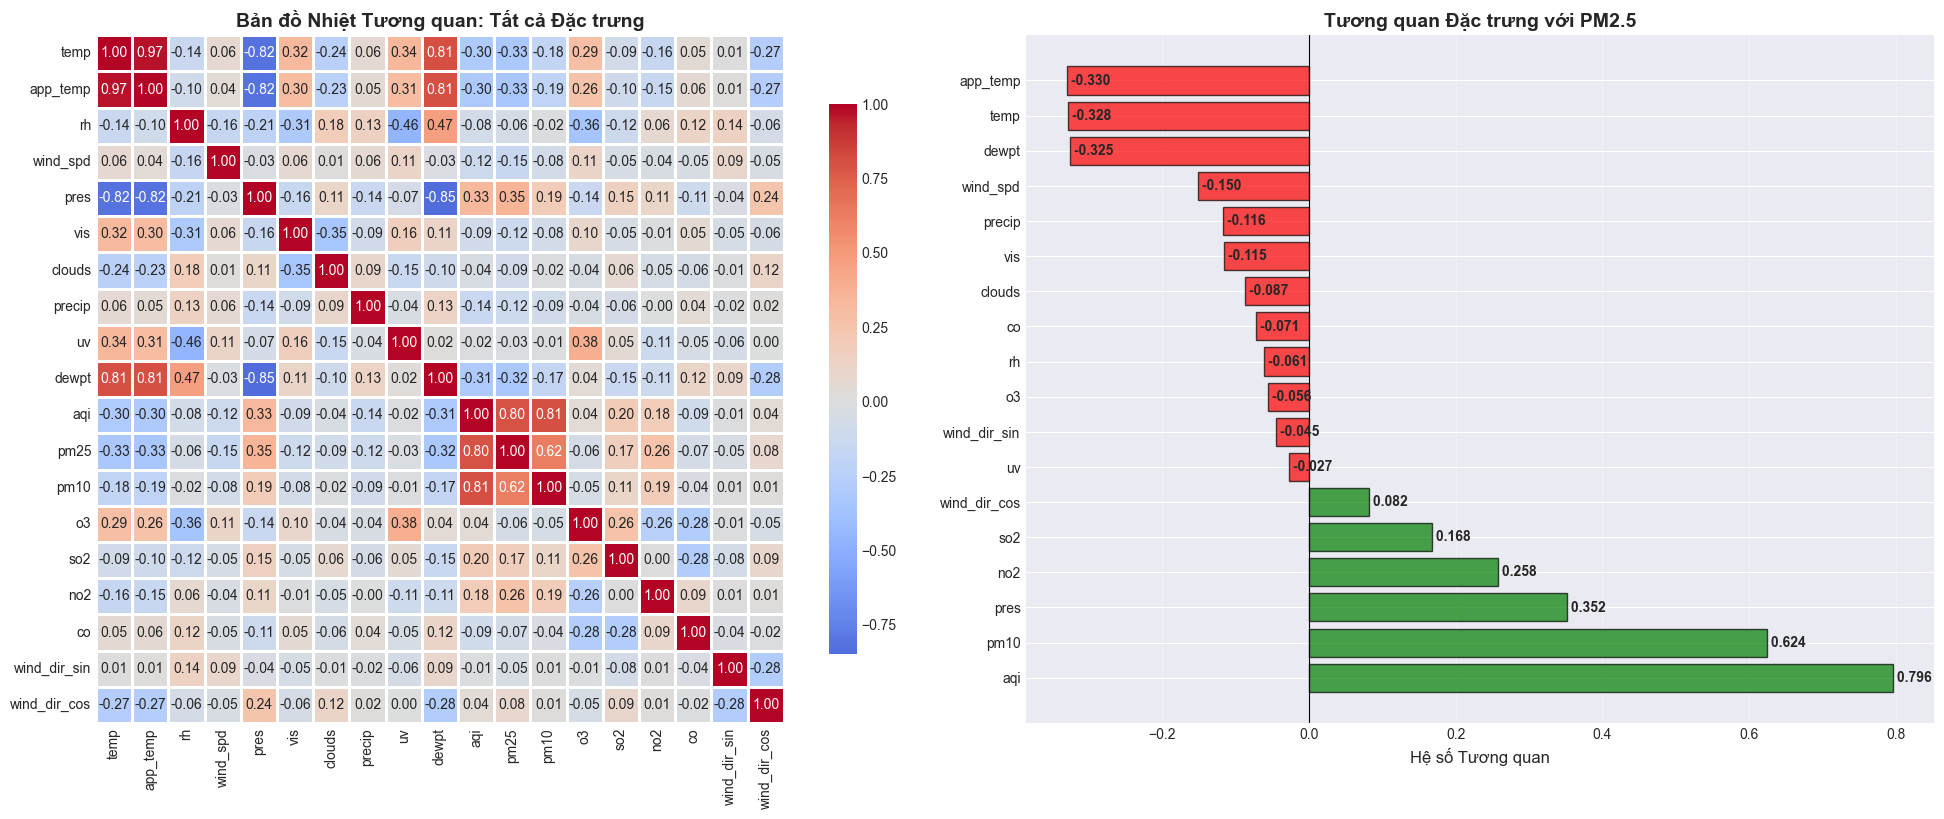

CÁC TƯƠNG QUAN CAO NHẤT VỚI PM2.5

TƯƠNG QUAN DƯƠNG (Giá trị cao hơn -> PM2.5 cao hơn):
--------------------------------------------------------------------------------
  aqi                 : +0.7959
  pm10                : +0.6243
  pres                : +0.3519
  no2                 : +0.2576
  so2                 : +0.1678
  wind_dir_cos        : +0.0820

TƯƠNG QUAN ÂM (Giá trị cao hơn -> PM2.5 thấp hơn):
--------------------------------------------------------------------------------
  app_temp            : -0.3297
  temp                : -0.3285
  dewpt               : -0.3248
  wind_spd            : -0.1503
  precip              : -0.1164
  vis                 : -0.1153
  clouds              : -0.0869
  co                  : -0.0713
  rh                  : -0.0608
  o3                  : -0.0557

PHÁT HIỆN ĐA CỘNG TUYẾN (|tương quan| > 0.9)
  temp                 <-> app_temp            : 0.9671

Khuyến nghị: Cân nhắc loại bỏ một đặc trưng từ mỗi cặp có tương quan cao

CÁC PHÁT 

In [12]:
## 5.3 Phân tích Tương quan

# Chọn các đặc trưng số (loại bỏ datetime và categorical)
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

# Tính ma trận tương quan
correlation_matrix = merged_df[numeric_cols].corr()

# Tạo figure với hai biểu đồ con
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Bản đồ nhiệt Tương quan Đầy đủ
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=axes[0])
axes[0].set_title('Bản đồ Nhiệt Tương quan: Tất cả Đặc trưng', fontsize=14, fontweight='bold')

# 2. Biểu đồ cột Tương quan với PM2.5
pm25_corr = correlation_matrix['pm25'].sort_values(ascending=False)
pm25_corr = pm25_corr[pm25_corr.index != 'pm25']  # Loại bỏ tự tương quan

colors = ['green' if x > 0 else 'red' for x in pm25_corr.values]
axes[1].barh(pm25_corr.index, pm25_corr.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Hệ số Tương quan', fontsize=12)
axes[1].set_title('Tương quan Đặc trưng với PM2.5', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

# Thêm nhãn giá trị
for i, (feature, corr) in enumerate(pm25_corr.items()):
    axes[1].text(corr, i, f' {corr:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# In các tương quan cao nhất
print("="*80)
print("CÁC TƯƠNG QUAN CAO NHẤT VỚI PM2.5")
print("="*80)
print("\nTƯƠNG QUAN DƯƠNG (Giá trị cao hơn -> PM2.5 cao hơn):")
print("-"*80)
positive_corr = pm25_corr[pm25_corr > 0].sort_values(ascending=False)
for feature, corr in positive_corr.head(10).items():
    print(f"  {feature:20s}: {corr:+.4f}")

print("\nTƯƠNG QUAN ÂM (Giá trị cao hơn -> PM2.5 thấp hơn):")
print("-"*80)
negative_corr = pm25_corr[pm25_corr < 0].sort_values()
for feature, corr in negative_corr.head(10).items():
    print(f"  {feature:20s}: {corr:+.4f}")

# Phát hiện vấn đề đa cộng tuyến
print("\n" + "="*80)
print("PHÁT HIỆN ĐA CỘNG TUYẾN (|tương quan| > 0.9)")
print("="*80)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for feat1, feat2, corr in high_corr_pairs:
        print(f"  {feat1:20s} <-> {feat2:20s}: {corr:.4f}")
    print("\nKhuyến nghị: Cân nhắc loại bỏ một đặc trưng từ mỗi cặp có tương quan cao")
else:
    print("  - Không phát hiện đa cộng tuyến nghiêm trọng")

print("\n" + "="*80)
print("CÁC PHÁT HIỆN QUAN TRỌNG CHO LỰA CHỌN MÔ HÌNH:")
print("="*80)

# Phân tích sức mạnh tương quan
strong_features = pm25_corr[abs(pm25_corr) > 0.5]
moderate_features = pm25_corr[(abs(pm25_corr) >= 0.3) & (abs(pm25_corr) <= 0.5)]
weak_features = pm25_corr[abs(pm25_corr) < 0.3]

print(f"- {len(strong_features)} đặc trưng dự đoán MẠNH (|corr| > 0.5):")
print(f"  {', '.join(strong_features.index.tolist())}")
print(f"\n- {len(moderate_features)} đặc trưng dự đoán TRUNG BÌNH (0.3 <= |corr| <= 0.5):")
print(f"  {', '.join(moderate_features.index.tolist())}")
print(f"\n- {len(weak_features)} đặc trưng dự đoán YẾU (|corr| < 0.3):")
print(f"  {', '.join(weak_features.index.tolist())}")

print("\nKhuyến nghị Mô hình dựa trên tương quan:")
if len(strong_features) >= 3:
    print("  -> Mô hình tuyến tính có thể hoạt động tốt (tồn tại mối quan hệ tuyến tính mạnh)")
if len(weak_features) > len(strong_features):
    print("  -> Khuyến nghị mô hình cây (có thể nắm bắt mối quan hệ phi tuyến)")
if len(high_corr_pairs) > 0:
    print("  -> Khuyến nghị sử dụng Regularization (Ridge/Lasso) để xử lý đa cộng tuyến")

/var/folders/nl/mcsjphcd59g353jxh4l500zc0000gn/T/ipykernel_4616/617856256.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='day_name', y='pm25', ax=axes[1, 1],


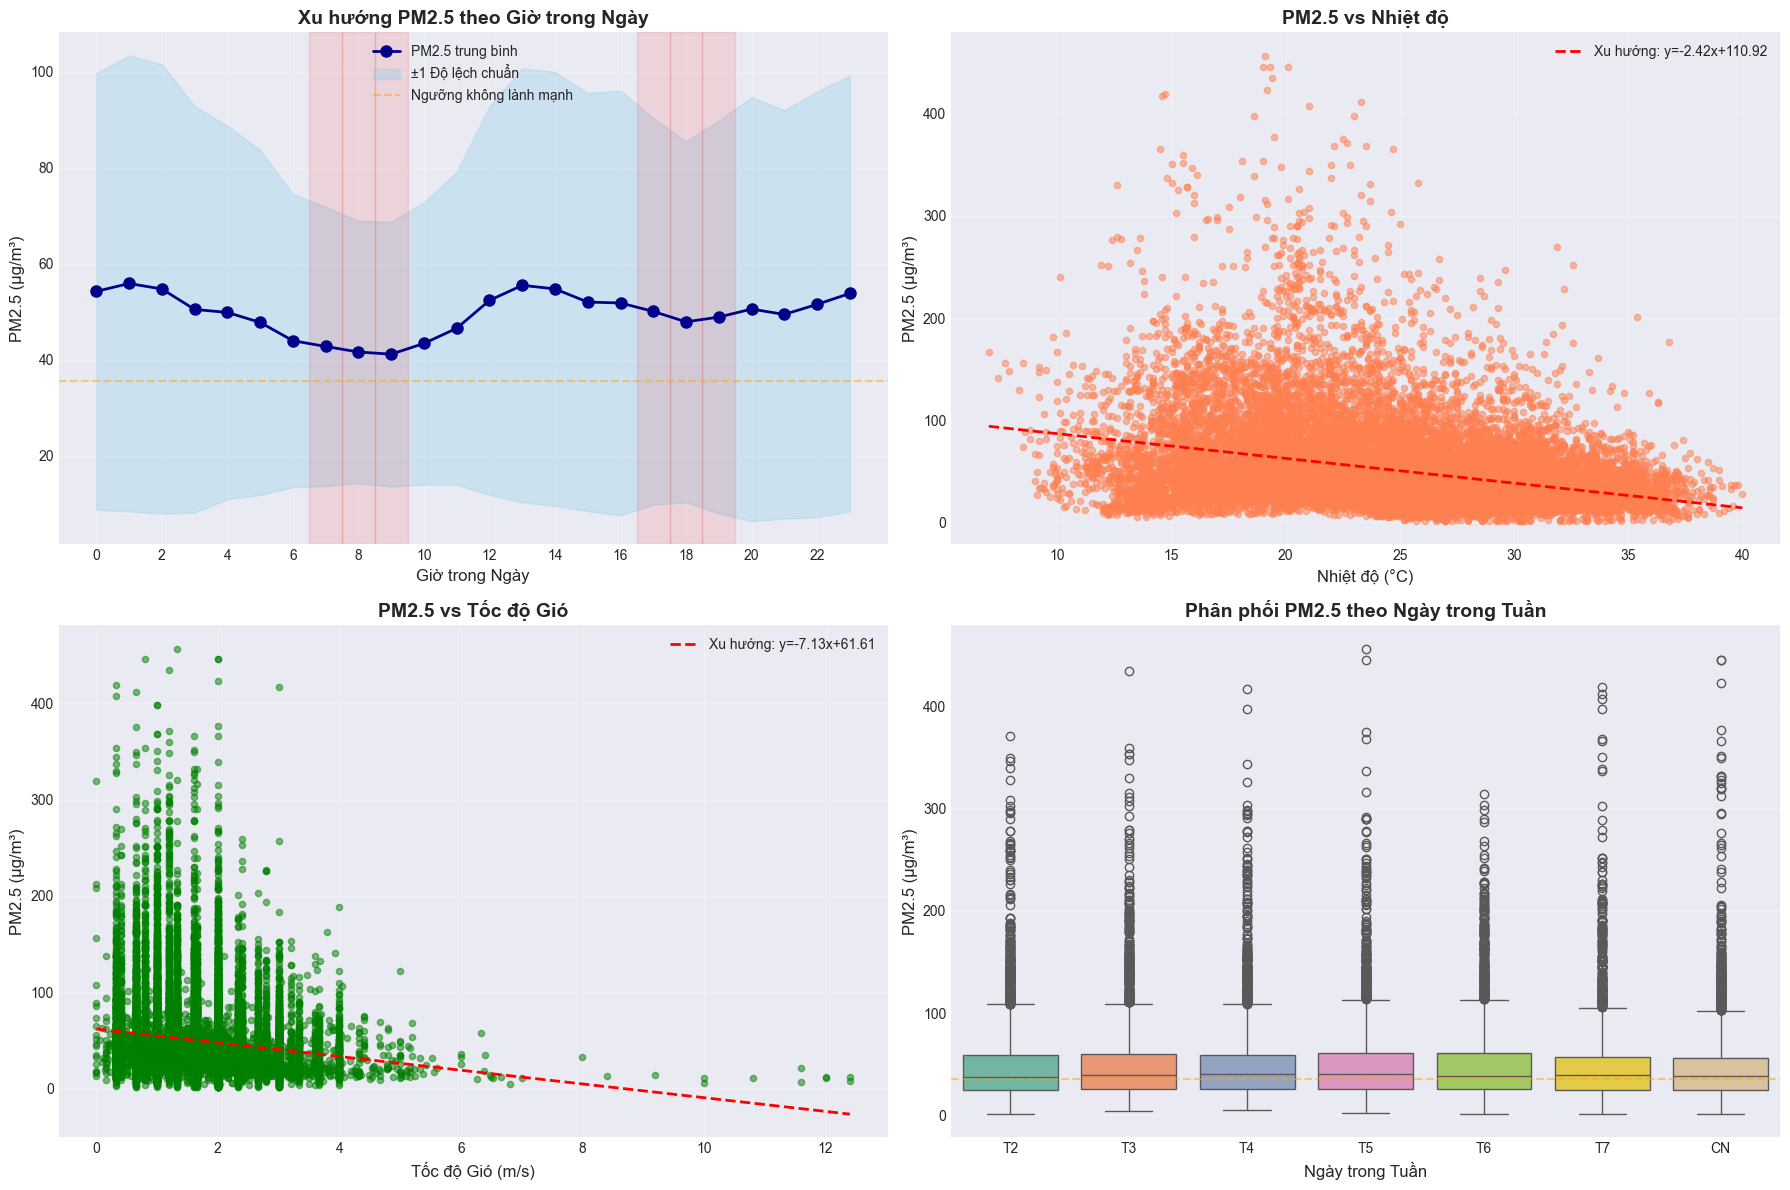

PHÂN TÍCH XU HƯỚNG THỜI GIAN

XU HƯỚNG THEO GIỜ:
--------------------------------------------------------------------------------
  Giờ PM2.5 cao nhất:   1:00 (55.88 μg/m³)
  Giờ PM2.5 thấp nhất:  9:00 (41.16 μg/m³)
  Biên độ biến thiên:   14.72 μg/m³

XU HƯỚNG THEO TUẦN:
--------------------------------------------------------------------------------
  PM2.5 trung bình theo ngày:
    T2: 49.82 μg/m³
    T3: 50.51 μg/m³
    T4: 50.66 μg/m³
    T5: 50.42 μg/m³
    T6: 49.72 μg/m³
    T7: 48.24 μg/m³
    CN: 48.02 μg/m³

CÁC PHÁT HIỆN QUAN TRỌNG VỀ XU HƯỚNG THỜI GIAN:
- Nên bao gồm các đặc trưng dựa trên giờ trong mô hình
- Cân nhắc mã hóa tuần hoàn cho giờ (biến đổi sin/cos)


In [13]:
## 5.4 Phân tích Xu hướng Thời gian

# Trích xuất các đặc trưng thời gian nếu chưa có
if 'hour' not in merged_df.columns:
    merged_df['hour'] = merged_df['datetime'].dt.hour
if 'day_of_week' not in merged_df.columns:
    merged_df['day_of_week'] = merged_df['datetime'].dt.dayofweek
if 'day' not in merged_df.columns:
    merged_df['day'] = merged_df['datetime'].dt.day

# Tạo phân tích thời gian toàn diện
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. PM2.5 theo Giờ trong Ngày
hourly_pm25 = merged_df.groupby('hour')['pm25'].agg(['mean', 'std', 'min', 'max'])
axes[0, 0].plot(hourly_pm25.index, hourly_pm25['mean'], marker='o', linewidth=2, 
                markersize=8, color='darkblue', label='PM2.5 trung bình')
axes[0, 0].fill_between(hourly_pm25.index, 
                        hourly_pm25['mean'] - hourly_pm25['std'],
                        hourly_pm25['mean'] + hourly_pm25['std'],
                        alpha=0.3, color='skyblue', label='±1 Độ lệch chuẩn')
axes[0, 0].axhline(y=35.5, color='orange', linestyle='--', alpha=0.5, label='Ngưỡng không lành mạnh')
axes[0, 0].set_xlabel('Giờ trong Ngày', fontsize=12)
axes[0, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0, 0].set_title('Xu hướng PM2.5 theo Giờ trong Ngày', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Đánh dấu giờ cao điểm
for hour in [7, 8, 9, 17, 18, 19]:
    axes[0, 0].axvspan(hour-0.5, hour+0.5, alpha=0.1, color='red')

# 2. PM2.5 vs Nhiệt độ
axes[0, 1].scatter(merged_df['temp'], merged_df['pm25'], alpha=0.5, s=20, color='coral')
axes[0, 1].set_xlabel('Nhiệt độ (°C)', fontsize=12)
axes[0, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0, 1].set_title('PM2.5 vs Nhiệt độ', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Thêm đường xu hướng
z = np.polyfit(merged_df['temp'].dropna(), merged_df.loc[merged_df['temp'].notna(), 'pm25'], 1)
p = np.poly1d(z)
axes[0, 1].plot(sorted(merged_df['temp']), p(sorted(merged_df['temp'])), 
                "r--", linewidth=2, label=f'Xu hướng: y={z[0]:.2f}x+{z[1]:.2f}')
axes[0, 1].legend()

# 3. PM2.5 vs Tốc độ Gió
axes[1, 0].scatter(merged_df['wind_spd'], merged_df['pm25'], alpha=0.5, s=20, color='green')
axes[1, 0].set_xlabel('Tốc độ Gió (m/s)', fontsize=12)
axes[1, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1, 0].set_title('PM2.5 vs Tốc độ Gió', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Thêm đường xu hướng
z = np.polyfit(merged_df['wind_spd'].dropna(), merged_df.loc[merged_df['wind_spd'].notna(), 'pm25'], 1)
p = np.poly1d(z)
axes[1, 0].plot(sorted(merged_df['wind_spd']), p(sorted(merged_df['wind_spd'])), 
                "r--", linewidth=2, label=f'Xu hướng: y={z[0]:.2f}x+{z[1]:.2f}')
axes[1, 0].legend()

# 4. Biểu đồ hộp: PM2.5 theo Ngày trong Tuần
day_names = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']
merged_df['day_name'] = merged_df['day_of_week'].map(dict(enumerate(day_names)))

sns.boxplot(data=merged_df, x='day_name', y='pm25', ax=axes[1, 1], 
            order=day_names, palette='Set2')
axes[1, 1].set_xlabel('Ngày trong Tuần', fontsize=12)
axes[1, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1, 1].set_title('Phân phối PM2.5 theo Ngày trong Tuần', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=35.5, color='orange', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Phân tích thống kê các xu hướng thời gian
print("="*80)
print("PHÂN TÍCH XU HƯỚNG THỜI GIAN")
print("="*80)

print("\nXU HƯỚNG THEO GIỜ:")
print("-"*80)
peak_hour = hourly_pm25['mean'].idxmax()
lowest_hour = hourly_pm25['mean'].idxmin()
print(f"  Giờ PM2.5 cao nhất:   {peak_hour}:00 ({hourly_pm25.loc[peak_hour, 'mean']:.2f} μg/m³)")
print(f"  Giờ PM2.5 thấp nhất:  {lowest_hour}:00 ({hourly_pm25.loc[lowest_hour, 'mean']:.2f} μg/m³)")
print(f"  Biên độ biến thiên:   {hourly_pm25['mean'].max() - hourly_pm25['mean'].min():.2f} μg/m³")

print("\nXU HƯỚNG THEO TUẦN:")
print("-"*80)
weekly_pm25 = merged_df.groupby('day_name')['pm25'].mean()
print("  PM2.5 trung bình theo ngày:")
for day in day_names:
    if day in weekly_pm25.index:
        print(f"    {day}: {weekly_pm25[day]:.2f} μg/m³")

print("\n" + "="*80)
print("CÁC PHÁT HIỆN QUAN TRỌNG VỀ XU HƯỚNG THỜI GIAN:")
print("="*80)
if peak_hour in [7, 8, 9, 17, 18, 19]:
    print("- PM2.5 cao nhất xảy ra trong giờ cao điểm -> Giao thông là yếu tố chính")
if hourly_pm25.loc[peak_hour, 'mean'] > hourly_pm25.loc[lowest_hour, 'mean'] * 1.5:
    print("- Biến thiên mạnh theo giờ -> Giờ trong ngày là đặc trưng quan trọng")
print("- Nên bao gồm các đặc trưng dựa trên giờ trong mô hình")
print("- Cân nhắc mã hóa tuần hoàn cho giờ (biến đổi sin/cos)")

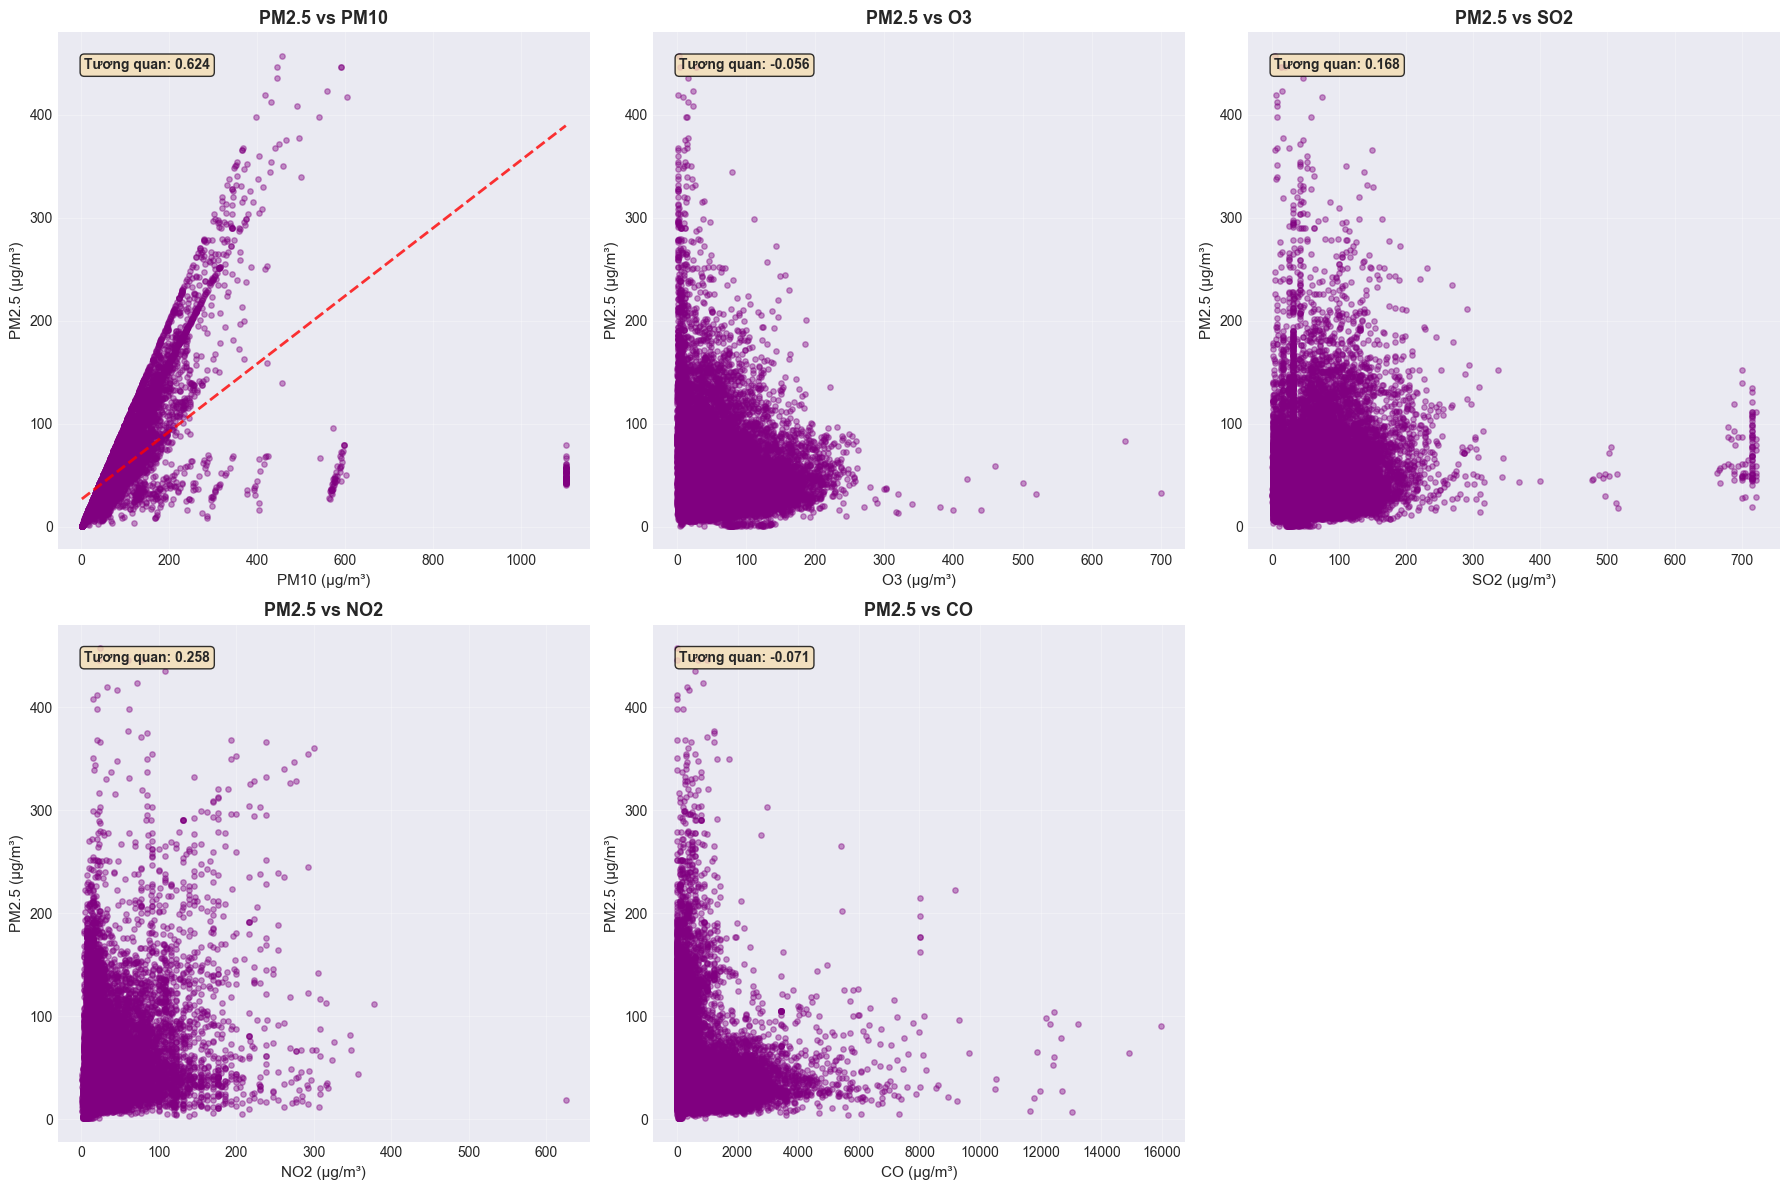

PHÂN TÍCH ĐẶC TRƯNG Ô NHIỄM

Thống kê Mô tả:
--------------------------------------------------------------------------------
            mean         std  min      max
pm10   70.314361   76.315692  1.0   1103.0
o3     53.604508   44.090166  0.0    700.0
so2    63.055253   62.621304  0.0    721.0
no2    31.642070   34.618823  1.0    625.0
co    603.981144  934.567183  0.0  15956.2
pm25   49.626878   40.199839  1.0    457.0

Tương quan với PM2.5:
--------------------------------------------------------------------------------
  PM10   -> PM2.5:  +0.6243  [TRUNG BÌNH] tăng
  O3     -> PM2.5:  -0.0557  [YẾU] giảm
  SO2    -> PM2.5:  +0.1678  [YẾU] tăng
  NO2    -> PM2.5:  +0.2576  [YẾU] tăng
  CO     -> PM2.5:  -0.0713  [YẾU] giảm

CÁC PHÁT HIỆN QUAN TRỌNG:
- Yếu tố ô nhiễm dự đoán mạnh nhất: PM10 (r=0.624)
- Tất cả các đặc trưng ô nhiễm đều có tương quan với PM2.5
- Các đặc trưng này rất quan trọng cho mô hình dự đoán


In [14]:
## 5.5 Phân tích Đặc trưng Ô nhiễm

# Chọn các đặc trưng liên quan đến ô nhiễm
pollution_features = ['pm10', 'o3', 'so2', 'no2', 'co']

# Tạo các biểu đồ phân tán theo cặp
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(pollution_features):
    if feature in merged_df.columns:
        axes[idx].scatter(merged_df[feature], merged_df['pm25'], alpha=0.4, s=15, color='purple')
        axes[idx].set_xlabel(f'{feature.upper()} (μg/m³)', fontsize=11)
        axes[idx].set_ylabel('PM2.5 (μg/m³)', fontsize=11)
        axes[idx].set_title(f'PM2.5 vs {feature.upper()}', fontsize=13, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        # Thêm hệ số tương quan
        corr = merged_df[[feature, 'pm25']].corr().iloc[0, 1]
        axes[idx].text(0.05, 0.95, f'Tương quan: {corr:.3f}', 
                      transform=axes[idx].transAxes, 
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                      verticalalignment='top', fontweight='bold')
        
        # Thêm đường xu hướng nếu tương quan đáng kể
        if abs(corr) > 0.3:
            z = np.polyfit(merged_df[feature].dropna(), 
                          merged_df.loc[merged_df[feature].notna(), 'pm25'], 1)
            p = np.poly1d(z)
            x_sorted = sorted(merged_df[feature].dropna())
            axes[idx].plot(x_sorted, p(x_sorted), "r--", linewidth=2, alpha=0.8)

# Xóa biểu đồ con thừa
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# So sánh thống kê
print("="*80)
print("PHÂN TÍCH ĐẶC TRƯNG Ô NHIỄM")
print("="*80)

print("\nThống kê Mô tả:")
print("-"*80)
pollution_stats = merged_df[pollution_features + ['pm25']].describe().T
print(pollution_stats[['mean', 'std', 'min', 'max']].to_string())

print("\nTương quan với PM2.5:")
print("-"*80)
for feature in pollution_features:
    if feature in merged_df.columns:
        corr = merged_df[[feature, 'pm25']].corr().iloc[0, 1]
        strength = "MẠNH" if abs(corr) > 0.7 else "TRUNG BÌNH" if abs(corr) > 0.4 else "YẾU"
        direction = "tăng" if corr > 0 else "giảm"
        print(f"  {feature.upper():6s} -> PM2.5:  {corr:+.4f}  [{strength}] {direction}")

print("\n" + "="*80)
print("CÁC PHÁT HIỆN QUAN TRỌNG:")
print("="*80)

# Xác định yếu tố dự đoán mạnh nhất
strongest_pollutant = max(pollution_features, 
                         key=lambda x: abs(merged_df[[x, 'pm25']].corr().iloc[0, 1]))
strongest_corr = merged_df[[strongest_pollutant, 'pm25']].corr().iloc[0, 1]

print(f"- Yếu tố ô nhiễm dự đoán mạnh nhất: {strongest_pollutant.upper()} (r={strongest_corr:.3f})")
print(f"- Tất cả các đặc trưng ô nhiễm đều có tương quan với PM2.5")
print(f"- Các đặc trưng này rất quan trọng cho mô hình dự đoán")

# Kiểm tra đa cộng tuyến giữa các đặc trưng ô nhiễm
pollution_corr = merged_df[pollution_features].corr()
high_corr_count = (pollution_corr.abs() > 0.8).sum().sum() - len(pollution_features)
if high_corr_count > 0:
    print(f"Cảnh báo: {high_corr_count//2} cặp đặc trưng ô nhiễm có tương quan cao")
    print("  -> Có thể gây ra vấn đề đa cộng tuyến trong mô hình tuyến tính")
    print("  -> Cân nhắc sử dụng regularization hoặc PCA")

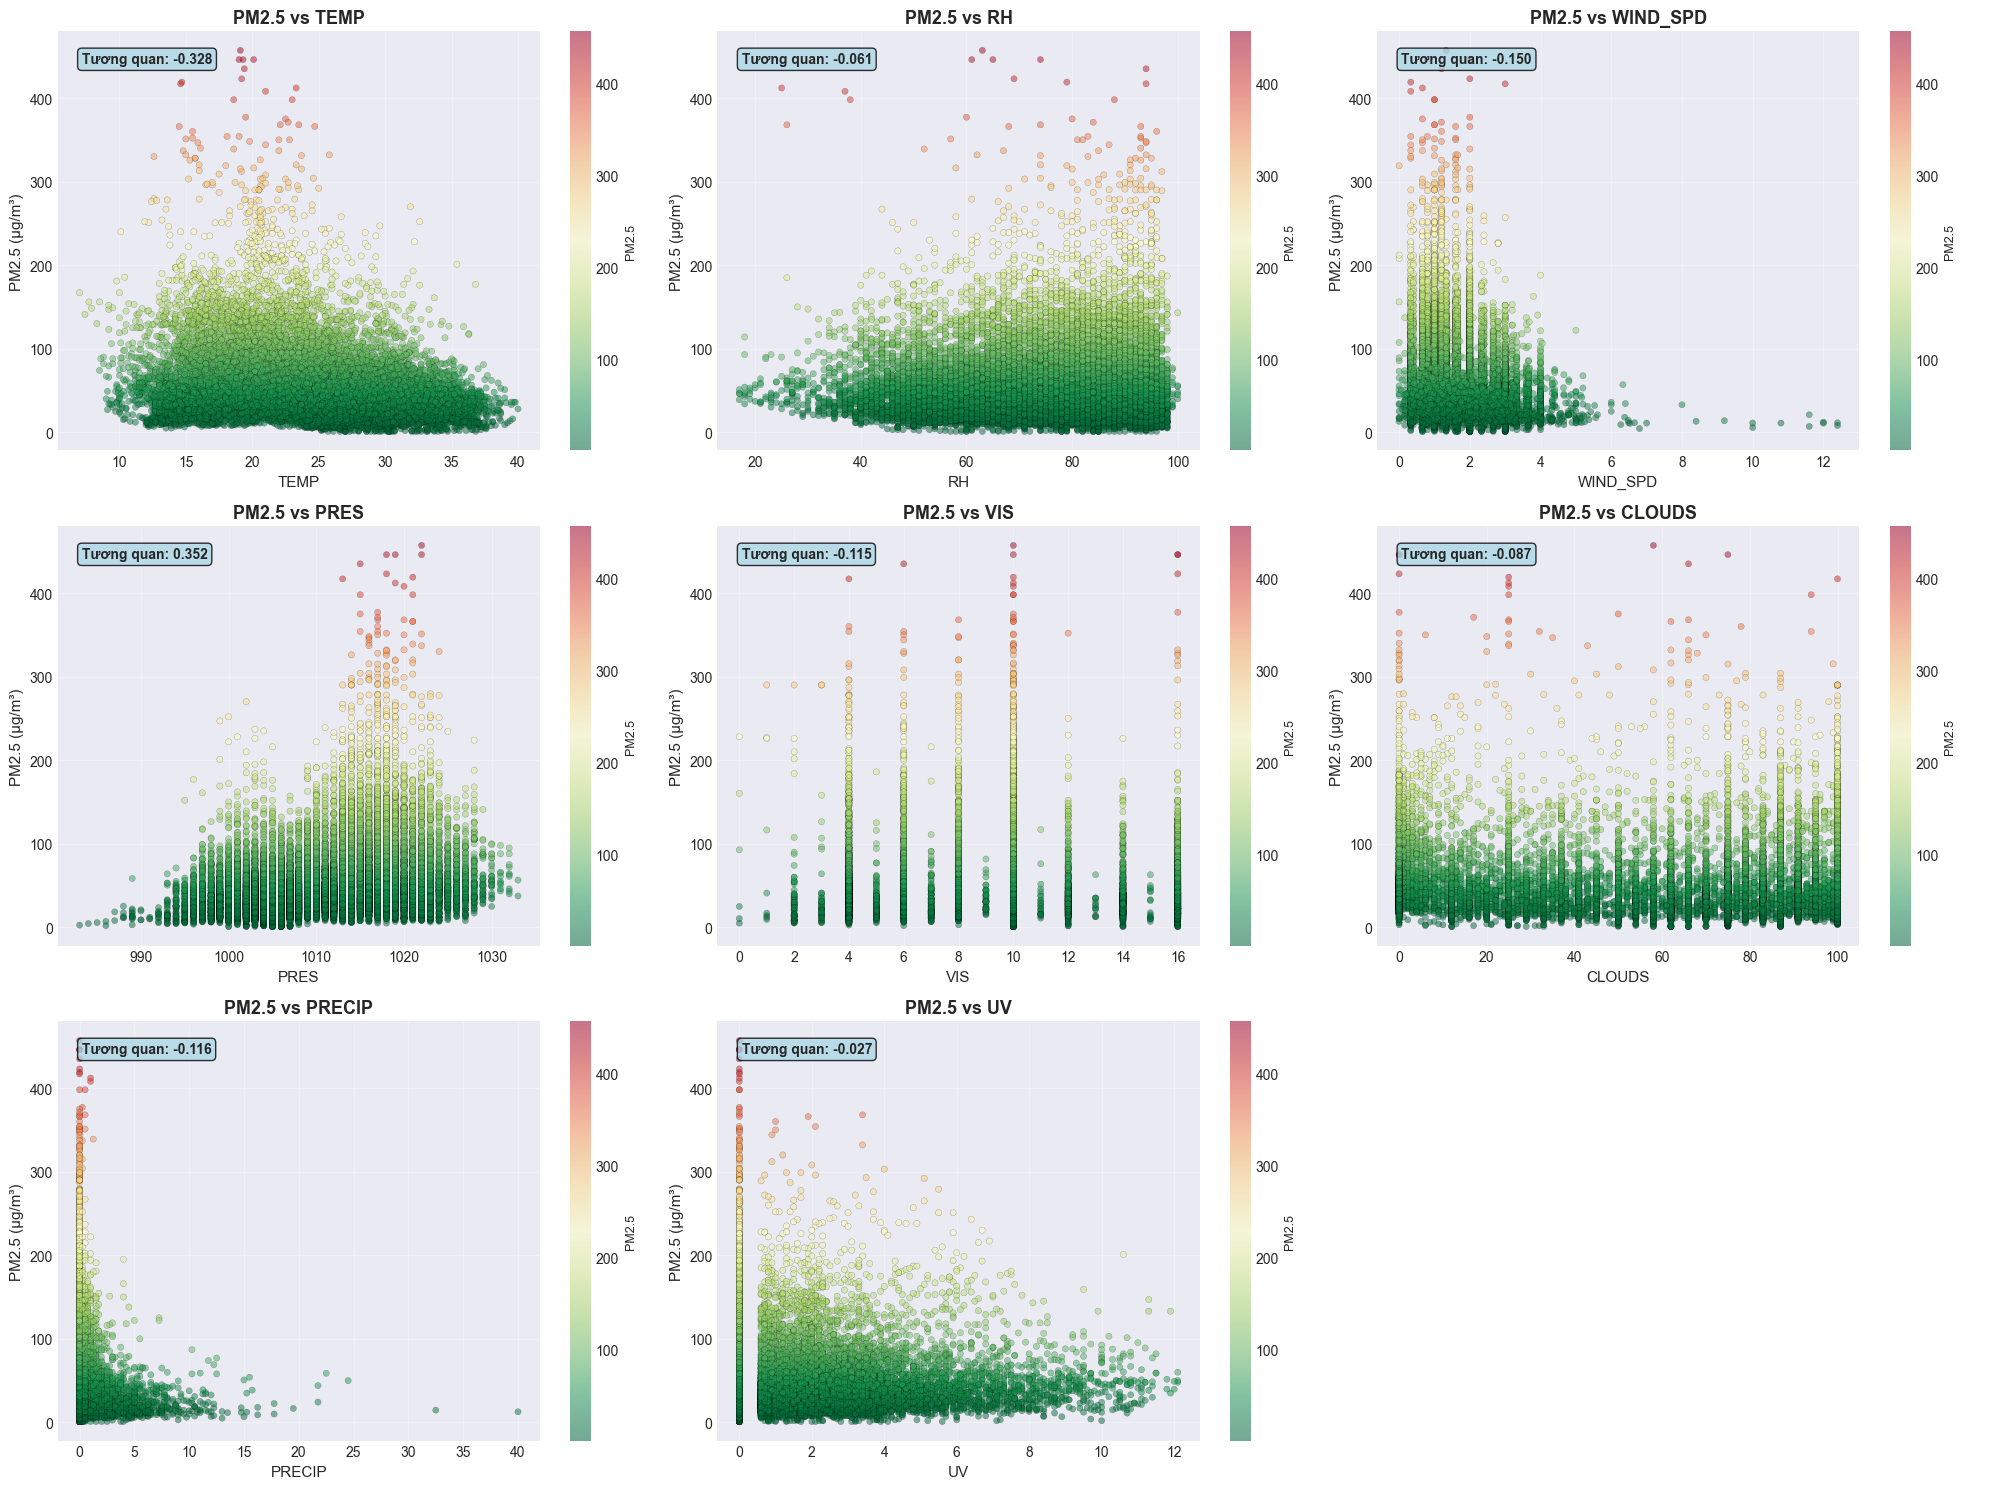

PHÂN TÍCH ĐẶC TRƯNG THỜI TIẾT

Thống kê Mô tả:
--------------------------------------------------------------------------------
                 mean        std    min     max
temp        25.323810   5.455107    7.0    40.0
rh          78.461455  14.985092   17.0   100.0
wind_spd     1.679912   0.847098    0.0    12.4
pres      1009.663836   7.398373  983.0  1033.0
vis         10.252321   2.674902    0.0    16.0
clouds      69.429820  32.881189    0.0   100.0
precip       0.318248   1.143260    0.0    40.0
uv           1.321932   1.918951    0.0    12.1

Tương quan với PM2.5:
--------------------------------------------------------------------------------
  TEMP         -> PM2.5:  -0.3285  [TRUNG BÌNH] giảm
  RH           -> PM2.5:  -0.0608  [YẾU] giảm
  WIND_SPD     -> PM2.5:  -0.1503  [YẾU] giảm
  PRES         -> PM2.5:  +0.3519  [TRUNG BÌNH] tăng
  VIS          -> PM2.5:  -0.1153  [YẾU] giảm
  CLOUDS       -> PM2.5:  -0.0869  [YẾU] giảm
  PRECIP       -> PM2.5:  -0.1164  [YẾU] giảm


In [15]:
## 5.6 Phân tích Đặc trưng Thời tiết

# Chọn các đặc trưng liên quan đến thời tiết
weather_features = ['temp', 'rh', 'wind_spd', 'pres', 'vis', 'clouds', 'precip', 'uv']

# Tạo phân tích thời tiết toàn diện
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

for idx, feature in enumerate(weather_features):
    if feature in merged_df.columns:
        # Tạo biểu đồ phân tán với màu gradient theo PM2.5
        scatter = axes[idx].scatter(merged_df[feature], merged_df['pm25'], 
                                   c=merged_df['pm25'], cmap='RdYlGn_r', 
                                   alpha=0.5, s=20, edgecolors='black', linewidths=0.2)
        axes[idx].set_xlabel(f'{feature.upper()}', fontsize=11)
        axes[idx].set_ylabel('PM2.5 (μg/m³)', fontsize=11)
        axes[idx].set_title(f'PM2.5 vs {feature.upper()}', fontsize=13, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        
        # Thêm thanh màu
        cbar = plt.colorbar(scatter, ax=axes[idx])
        cbar.set_label('PM2.5', fontsize=9)
        
        # Thêm hệ số tương quan
        corr = merged_df[[feature, 'pm25']].corr().iloc[0, 1]
        axes[idx].text(0.05, 0.95, f'Tương quan: {corr:.3f}', 
                      transform=axes[idx].transAxes, 
                      bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8),
                      verticalalignment='top', fontweight='bold')

# Xóa biểu đồ con thừa
axes[-1].axis('off')

plt.tight_layout()
plt.show()

# Tạo phân tích phân loại điều kiện thời tiết
print("="*80)
print("PHÂN TÍCH ĐẶC TRƯNG THỜI TIẾT")
print("="*80)

print("\nThống kê Mô tả:")
print("-"*80)
weather_stats = merged_df[weather_features].describe().T
print(weather_stats[['mean', 'std', 'min', 'max']].to_string())

print("\nTương quan với PM2.5:")
print("-"*80)
weather_corr_with_pm25 = []
for feature in weather_features:
    if feature in merged_df.columns:
        corr = merged_df[[feature, 'pm25']].corr().iloc[0, 1]
        strength = "MẠNH" if abs(corr) > 0.5 else "TRUNG BÌNH" if abs(corr) > 0.3 else "YẾU"
        direction = "tăng" if corr > 0 else "giảm"
        weather_corr_with_pm25.append((feature, corr, strength, direction))
        print(f"  {feature.upper():12s} -> PM2.5:  {corr:+.4f}  [{strength}] {direction}")

# Sắp xếp theo giá trị tuyệt đối tương quan
weather_corr_with_pm25.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n" + "="*80)
print("CÁC PHÁT HIỆN QUAN TRỌNG TỪ ĐẶC TRƯNG THỜI TIẾT:")
print("="*80)

print("\n1. TOP 3 Đặc trưng Thời tiết Quan trọng nhất:")
for i, (feature, corr, strength, direction) in enumerate(weather_corr_with_pm25[:3], 1):
    print(f"   {i}. {feature.upper():12s}: {corr:+.4f} - ", end="")
    if feature == 'wind_spd' and corr < 0:
        print("Tốc độ gió cao hơn phân tán chất ô nhiễm")
    elif feature == 'rh' and corr > 0:
        print("Độ ẩm cao hơn giữ chất ô nhiễm gần mặt đất")
    elif feature == 'temp':
        print("Nhiệt độ ảnh hưởng đến sự trộn lẫn khí quyển")
    elif feature == 'vis' and corr < 0:
        print("Tầm nhìn xa tốt hơn = không khí sạch hơn")
    elif feature == 'precip' and corr < 0:
        print("Mưa rửa trôi chất ô nhiễm")
    else:
        print(f"Yếu tố dự đoán {strength}")

print("\n2. Xu hướng Thời tiết & PM2.5:")

# Phân tích phân loại tốc độ gió
wind_low = merged_df[merged_df['wind_spd'] < 2]['pm25'].mean()
wind_high = merged_df[merged_df['wind_spd'] >= 2]['pm25'].mean()
print(f"   - Gió yếu (<2 m/s):    PM2.5 TB = {wind_low:.2f} μg/m³")
print(f"   - Gió mạnh (>=2 m/s):  PM2.5 TB = {wind_high:.2f} μg/m³")
print(f"   - Chênh lệch:          {wind_low - wind_high:.2f} μg/m³ ({(wind_low-wind_high)/wind_high*100:+.1f}%)")

# Phân tích phân loại độ ẩm
rh_low = merged_df[merged_df['rh'] < 60]['pm25'].mean()
rh_high = merged_df[merged_df['rh'] >= 60]['pm25'].mean()
print(f"\n   - Độ ẩm thấp (<60%):   PM2.5 TB = {rh_low:.2f} μg/m³")
print(f"   - Độ ẩm cao (>=60%):   PM2.5 TB = {rh_high:.2f} μg/m³")
print(f"   - Chênh lệch:          {rh_high - rh_low:.2f} μg/m³ ({(rh_high-rh_low)/rh_low*100:+.1f}%)")

# Phân tích ảnh hưởng lượng mưa
rainy = merged_df[merged_df['precip'] > 0]['pm25'].mean()
no_rain = merged_df[merged_df['precip'] == 0]['pm25'].mean()
print(f"\n   - Có mưa:              PM2.5 TB = {rainy:.2f} μg/m³")
print(f"   - Không mưa:           PM2.5 TB = {no_rain:.2f} μg/m³")
print(f"   - Tác động mưa:        {rainy - no_rain:.2f} μg/m³ ({(rainy-no_rain)/no_rain*100:+.1f}%)")

print("\n3. Khuyến nghị Kỹ thuật Đặc trưng:")
print("   - Giữ tất cả đặc trưng thời tiết - chúng nắm bắt các khía cạnh khác nhau")
print("   - Cân nhắc các đặc trưng tương tác: wind_spd x temp, rh x temp")
print("   - Tạo các nhóm phân loại cho đặc trưng liên tục")
print("   - Đặc trưng đa thức có thể giúp nắm bắt mối quan hệ phi tuyến")